<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/Fabric_Classification_model__exp_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gc
import tensorflow as tf

# Clear TensorFlow session
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

print("Memory cleared. Please try running the training cells again.")

Memory cleared. Please try running the training cells again.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import os

# Define paths
DATASET_PATH = '/content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras'

# Hyperparameters
IMG_SIZE = (224, 224) # MobileNetV2 input size
BATCH_SIZE = 4 # Further reduced batch size to avoid OOM - Try 4 or even 2 if crashes persist
NUM_CLASSES = None # This will be determined automatically

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# Define paths
# Corrected DATASET_PATH to point to the root containing 'train' and 'test' folders
DATASET_ROOT = '/content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/fabric_project/Fabric_Type_ Dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras'

# Hyperparameters
IMG_SIZE = (224, 224) # MobileNetV2 input size
BATCH_SIZE = 8 # Further reduced batch size to avoid OOM
NUM_CLASSES = None # This will be determined automatically

# Create a `Rescaling` layer for image normalization
rescale = tf.keras.Sequential([
  layers.Rescaling(1./255)
])

# Create a data augmentation pipeline for training images
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2) # Adding random contrast
])

# Check if the dataset root path exists
if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError(f"Dataset root path not found: {DATASET_ROOT}")

# Load the dataset using image_dataset_from_directory
# Load training dataset from the 'train' subdirectory
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_ROOT, 'train'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset from the 'test' subdirectory
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_ROOT, 'test'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Determine the number of classes from the training dataset
NUM_CLASSES = len(train_ds_raw.class_names)
class_names = train_ds_raw.class_names # Store class names before transformations
print(f"Number of classes found: {NUM_CLASSES}")
print(f"Class names: {class_names}")

# Apply data augmentation ONLY to the training dataset, then apply rescaling
train_ds = train_ds_raw.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Apply only rescaling to the validation dataset
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Mounted at /content/drive
Found 8281 files belonging to 9 classes.
Found 920 files belonging to 9 classes.
Number of classes found: 9
Class names: ['Chiffon', 'Cotton_', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']


In [ ]:
def build_model(num_classes):
    # Load the MobileNetV2 base model, pre-trained on ImageNet
    base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

    # Create the model by adding custom top layers
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs, training=False) # Important for BatchNormalization in base model
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x) # Dropout for regularization
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,274,633 (8.68 MB)

 Trainable params: 2,237,961 (8.54 MB)

 Non-trainable params: 36,672 (143.25 KB)

In [ ]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

# Setup ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=True,   # Save only the best model
    mode='max',            # 'max' because we want to maximize accuracy
    verbose=1
)

In [ ]:
base_model.trainable = False # Freeze the base model

# Compile the model for the warm-up phase
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3), # Standard learning rate for warm-up
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 1: Warm-up Training (10 Epochs) ---")
try:
    history_phase1 = model.fit(
        train_ds,
        epochs=10,
        validation_data=val_ds,
        callbacks=[checkpoint_callback]
    )
except tf.errors.ResourceExhaustedError:
    print("\nError: Out of memory during Phase 1 training. Try reducing BATCH_SIZE in cell ff510882.")
except Exception as e:
    print(f"\nAn unexpected error occurred during Phase 1 training: {e}")


--- Phase 1: Warm-up Training (10 Epochs) ---
Epoch 1/10
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.4270 - loss: 1.8627
Epoch 1: val_accuracy improved from None to 0.57717, saving model to /content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 751s 701ms/step - accuracy: 0.5160 - loss: 1.5418 - val_accuracy: 0.5772 - val_loss: 1.2679
Epoch 2/10
1032/1036 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6296 - loss: 1.1440
Epoch 2: val_accuracy improved from 0.57717 to 0.57935, saving model to /content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6300 - loss: 1.1260 - val_accuracy: 0.5793 - val_loss: 1.2894
Epoch 3/10
1035/1036 ━━

In [ ]:
base_model.trainable = True # Unfreeze the base model

# It's good practice to set a smaller learning rate for fine-tuning
# This ensures the model doesn't 'forget' what it learned previously
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), # Very low learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 2: Fine-Tuning (40 Epochs) ---")
try:
    history_phase2 = model.fit(
        train_ds,
        epochs=40, # Additional 40 epochs
        validation_data=val_ds,
        callbacks=[checkpoint_callback]
    )
except tf.errors.ResourceExhaustedError:
    print("\nError: Out of memory during Phase 2 training. Try reducing BATCH_SIZE in cell ff510882.")
except Exception as e:
    print(f"\nAn unexpected error occurred during Phase 2 training: {e}")


--- Phase 2: Fine-Tuning (40 Epochs) ---
Epoch 1/40
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3781 - loss: 2.5732
Epoch 1: val_accuracy did not improve from 0.60543
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 125s 67ms/step - accuracy: 0.4228 - loss: 2.3176 - val_accuracy: 0.4902 - val_loss: 2.4212
Epoch 2/40
1035/1036 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5673 - loss: 1.5005
Epoch 2: val_accuracy did not improve from 0.60543
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.5827 - loss: 1.4288 - val_accuracy: 0.5185 - val_loss: 2.1126
Epoch 3/40
1035/1036 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6756 - loss: 1.0165
Epoch 3: val_accuracy did not improve from 0.60543
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.6853 - loss: 0.9866 - val_accuracy: 0.5239 - val_loss: 1.9074
Epoch 4/40
1035/1036 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7462 - loss: 0.7388
Epoch 4: val_accuracy did not improve from 0.60543
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 37s

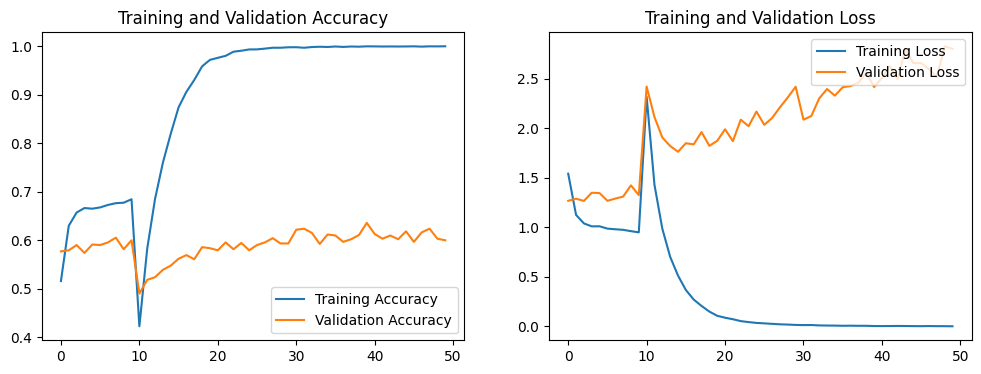

In [ ]:
def plot_history(history1, history2):
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history_phase1, history_phase2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


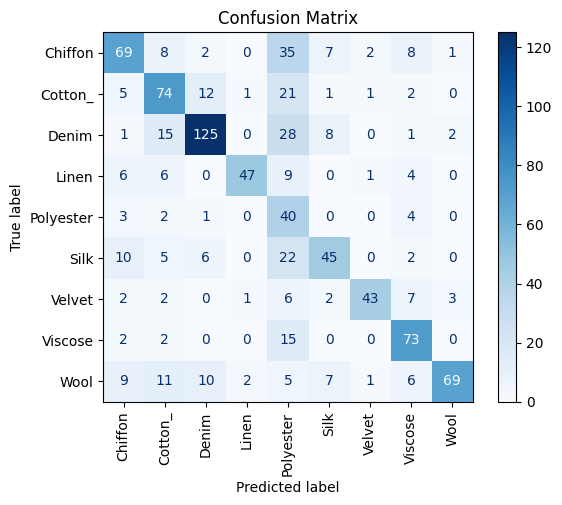

In [ ]:
# Load the best saved model for final evaluation
final_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

# Predict on the validation set
val_labels = []
val_predictions = []

for images, labels in val_ds:
    preds = final_model.predict(images)
    val_predictions.extend(np.argmax(preds, axis=1))
    val_labels.extend(labels.numpy())

# Generate Confusion Matrix
cm = confusion_matrix(val_labels, val_predictions)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from google.colab import files
import io

print("Please upload an image file (e.g., .jpg, .jpeg, .png) for prediction:")

uploaded = files.upload()

if uploaded:
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
        # Use the first uploaded file for prediction
        UPLOADED_IMAGE_PATH = os.path.join('/content/', fn)
        print(f"Using uploaded image: {UPLOADED_IMAGE_PATH}")
        break # Only process the first uploaded file
else:
    print("No file uploaded.")

Please upload an image file (e.g., .jpg, .jpeg, .png) for prediction:


Saving linen.webp to linen.webp
User uploaded file "linen.webp"
Using uploaded image: /content/linen.webp


Using uploaded image for prediction: /content/linen.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted fabric type is: Polyester
Confidence: 1.00


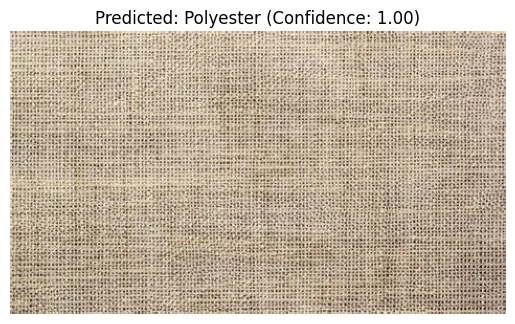

In [ ]:
from tensorflow.keras.preprocessing import image

def preprocess_image_for_prediction(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = rescale(img_array) # Apply the same rescaling as during training
    return img_array

# Use the uploaded image path if available, otherwise fallback to the example path
if 'UPLOADED_IMAGE_PATH' in locals() and os.path.exists(UPLOADED_IMAGE_PATH):
    current_image_path = UPLOADED_IMAGE_PATH
    print(f"Using uploaded image for prediction: {current_image_path}")
else:
    # Fallback to the original test image path if no file was uploaded
    current_image_path = os.path.join(DATASET_ROOT, 'test', 'Wool', 'Wool_1.jpeg')
    print(f"No image uploaded, using default test image: {current_image_path}")

# Check if the current image path exists
if not os.path.exists(current_image_path):
    raise FileNotFoundError(f"Image path not found: {current_image_path}. Please ensure the file exists and the path/filename is correct (check case and extension).")

processed_image = preprocess_image_for_prediction(current_image_path)

# Make prediction
predictions = final_model.predict(processed_image)
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_class_name = class_names[predicted_class_index]
confidence = predictions[0][predicted_class_index]

print(f"The predicted fabric type is: {predicted_class_name}")
print(f"Confidence: {confidence:.2f}")

# Display the image
plt.imshow(image.load_img(current_image_path))
plt.title(f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()

In [ ]:
final_model.save(MODEL_SAVE_PATH)
print(f"Model saved again to: {MODEL_SAVE_PATH}")

Model saved again to: /content/drive/MyDrive/Fivora/Classification_model/fabric_expert_v2.keras
